# Nearest Neigbours
___

In [43]:
import os
from pathlib import Path
from subprocess import call
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch
import random
from PIL import Image

def opF(path):
    p = Path(path)
    os.startfile(p) # for Windows
    #_ = call(['open',p]) # for Mac/Linux

In [2]:
colours = np.random.random([400,3])

In [3]:
colours 

array([[0.20710796, 0.91287686, 0.77399032],
       [0.33083072, 0.56644146, 0.70597299],
       [0.24757678, 0.64160625, 0.84752442],
       ...,
       [0.85257437, 0.17695235, 0.2692806 ],
       [0.51890715, 0.58723269, 0.51912214],
       [0.38468244, 0.56511111, 0.58123384]])

In [4]:
colGrid = colours.reshape([20,20,3])

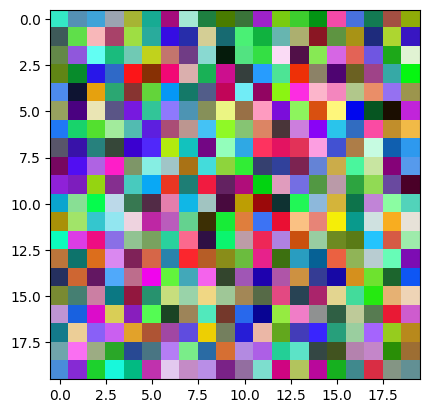

In [5]:
fig = plt.figure()
plt.imshow(colGrid)
plt.show()

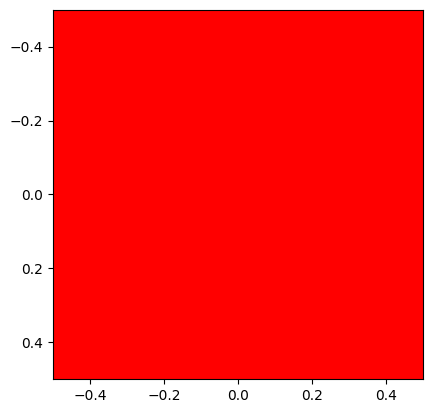

In [6]:
searchColour = [1.,0.,0.]
fig = plt.figure()
plt.imshow([[searchColour]])
plt.show()

In [7]:
nbrs = NearestNeighbors(n_neighbors=300).fit(colours)
dists, indxs = nbrs.kneighbors([searchColour])
indxs

array([[ 64,  73, 232, 267, 338, 186, 188, 397, 114, 253, 251, 211, 152,
        153,  89, 151,  66, 262, 275, 258, 268,  34, 281, 304, 345,  65,
        369, 265, 242,  56, 392,  18,  84, 314, 230, 167, 271, 190,  91,
        260,  23,  69, 312, 296,   6, 329, 379, 359, 173, 264, 138,  82,
        126, 156, 160, 293, 110, 220, 131, 344, 394,  46, 178, 210,  36,
        247, 238,  97,  76, 234, 137,  77, 225,  15, 310, 199, 282, 269,
        189, 327,  53, 284, 385, 205, 389, 148, 209, 183, 215,  99, 175,
        132, 300, 139, 228, 346,  74, 163, 255,  47,  19, 292, 322, 256,
          4,  60, 348, 108, 375,  75, 349, 311, 302, 318, 100, 140, 206,
         40, 248, 127,  70,   9, 289, 226, 143,  45, 101, 390, 279, 290,
        337, 164,  33, 272, 374, 324, 323,  11, 118,  35, 103, 276, 119,
        393, 198,  93, 376, 245, 352,  20, 358, 181, 339,  95, 233, 334,
         38, 398,  10, 333, 182, 285, 362, 250, 235, 335, 195, 241, 171,
         88, 194, 313, 326, 280,  12, 180,  81, 270

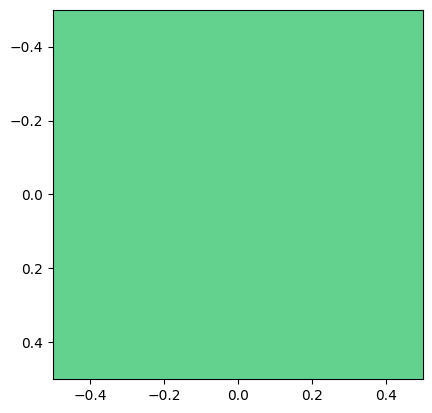

In [10]:
match = colours[indxs[0][299]]
fig = plt.figure()
plt.imshow([[match]])
plt.show()

# Clustering
___
### K-Means

In [14]:
kmeans = KMeans(n_clusters = 6, n_init="auto").fit(colours)
kmeans.labels_

array([2, 2, 2, 0, 1, 2, 4, 0, 5, 3, 5, 4, 3, 3, 3, 4, 2, 5, 1, 3, 5, 3,
       0, 1, 3, 2, 2, 5, 0, 5, 3, 3, 2, 0, 5, 3, 1, 5, 3, 5, 3, 4, 0, 3,
       0, 1, 1, 5, 0, 5, 3, 3, 0, 5, 3, 4, 1, 4, 3, 0, 3, 3, 2, 2, 1, 1,
       4, 0, 3, 4, 5, 2, 3, 1, 1, 5, 5, 4, 2, 3, 2, 5, 1, 3, 5, 3, 2, 5,
       5, 1, 0, 5, 3, 4, 0, 4, 0, 1, 4, 1, 3, 5, 0, 5, 4, 2, 4, 2, 3, 0,
       1, 0, 4, 3, 1, 0, 2, 5, 5, 4, 2, 3, 3, 0, 2, 4, 1, 0, 2, 3, 3, 1,
       5, 4, 4, 2, 2, 4, 1, 1, 5, 5, 2, 5, 5, 2, 3, 2, 5, 0, 2, 1, 1, 1,
       0, 2, 1, 0, 2, 2, 5, 4, 4, 4, 3, 0, 0, 1, 2, 3, 3, 5, 5, 5, 2, 1,
       3, 0, 5, 2, 4, 4, 3, 4, 2, 2, 1, 5, 1, 5, 4, 3, 0, 2, 3, 0, 3, 3,
       5, 5, 2, 0, 3, 0, 5, 5, 4, 2, 0, 5, 1, 1, 5, 3, 0, 1, 5, 4, 0, 2,
       1, 0, 2, 0, 0, 4, 4, 3, 5, 3, 1, 2, 1, 0, 1, 1, 2, 0, 1, 0, 2, 4,
       4, 4, 0, 3, 2, 4, 5, 3, 0, 1, 4, 1, 0, 3, 3, 2, 1, 0, 1, 5, 1, 4,
       5, 1, 2, 1, 1, 1, 3, 4, 5, 2, 2, 1, 3, 0, 0, 4, 5, 1, 5, 2, 4, 4,
       3, 2, 4, 5, 4, 5, 4, 1, 5, 5, 1, 3, 5, 2, 3,

In [15]:
indices0 = [i for i, x in enumerate(kmeans.labels_) if x == 0]
cluster0 = [colours[i] for i in indices0]
cluster0

[array([0.61126775, 0.64555842, 0.69596005]),
 array([0.64547928, 0.91114074, 0.83396426]),
 array([0.9726612 , 0.7204658 , 0.72882468]),
 array([0.83210957, 0.81105336, 0.58454698]),
 array([0.67780504, 0.68985013, 0.43871509]),
 array([0.3872964 , 0.99950652, 0.95414126]),
 array([0.44191958, 0.78894299, 0.7064746 ]),
 array([0.53758527, 0.85134278, 0.82207654]),
 array([0.98395907, 0.8617859 , 0.96090063]),
 array([0.8859571 , 0.95397985, 0.83022338]),
 array([0.8573193 , 0.68772157, 0.67904376]),
 array([0.44568849, 0.92810052, 0.96722159]),
 array([0.98949912, 0.7099436 , 0.79950148]),
 array([0.69574901, 0.78044973, 0.54782664]),
 array([0.91937941, 0.9009085 , 0.70757383]),
 array([0.92299352, 0.96193596, 0.51735445]),
 array([0.99933228, 0.61073694, 0.75367539]),
 array([0.99805141, 0.96494214, 0.48286964]),
 array([0.63737289, 0.92189531, 0.61464584]),
 array([0.73725516, 0.58899616, 0.56801531]),
 array([0.57922242, 0.99723987, 0.73702567]),
 array([0.99125896, 0.61966548, 0.

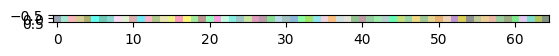

In [16]:
fig = plt.figure()
plt.imshow([cluster0])
plt.show()

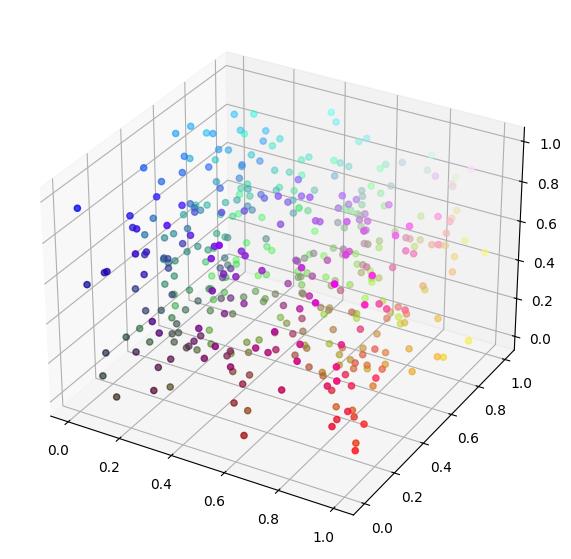

In [17]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
cs = [[x[0], x[1], x[2]]for x in colours]
ax.scatter([c[0] for c in colours], [c[1] for c in colours], [c[2] for c in colours], color = cs)
plt.show()

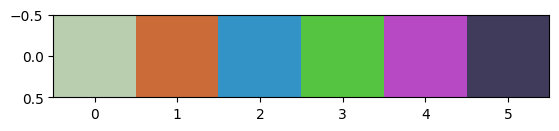

In [18]:
centres = kmeans.cluster_centers_
fig = plt.figure()
plt.imshow([centres])
plt.show()

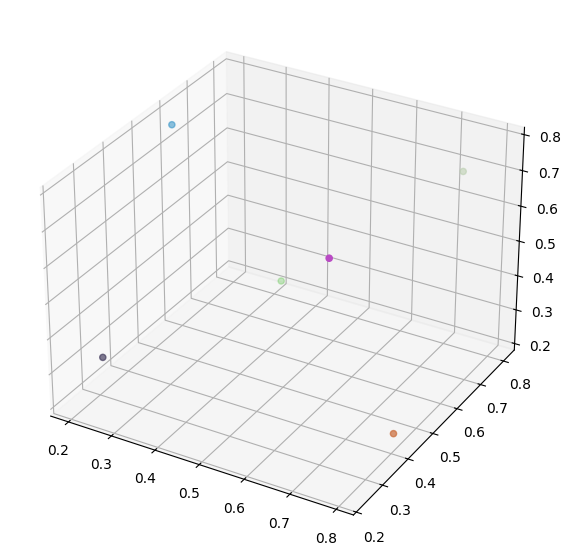

In [19]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
cs = [[x[0], x[1], x[2]]for x in centres]
ax.scatter([c[0] for c in centres], [c[1] for c in centres], [c[2] for c in centres], color = cs)

#plt.axis('off')
plt.show()

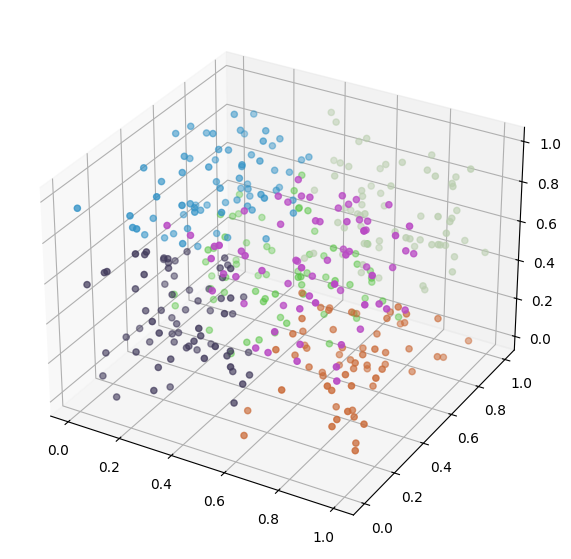

In [20]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

cs = [centres[kmeans.predict([x])] for x in colours]
ax.scatter([c[0] for c in colours], [c[1] for c in colours], [c[2] for c in colours], color = cs)

#plt.axis('off')
plt.show()

In [55]:
sample_image = Image.open('Parthenon.jpg')
opF('Parthenon.jpg')

In [56]:
sample_image = np.array(sample_image, dtype=np.float64)/255
sample_image

array([[[0.00392157, 0.32941176, 0.5254902 ],
        [0.00392157, 0.32941176, 0.5254902 ],
        [0.00392157, 0.32941176, 0.5254902 ],
        ...,
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ]],

       [[0.00784314, 0.33333333, 0.52941176],
        [0.00784314, 0.33333333, 0.52941176],
        [0.00784314, 0.33333333, 0.52941176],
        ...,
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ]],

       [[0.01568627, 0.3372549 , 0.53333333],
        [0.01568627, 0.3372549 , 0.53333333],
        [0.01568627, 0.3372549 , 0.53333333],
        ...,
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ],
        [0.12156863, 0.36078431, 0.5372549 ]],

       ...,

       [[0.79215686, 0.74901961, 0.7254902 ],
        [0.74901961, 0.69803922, 0.6627451 ],
        [0.81960784, 0

In [57]:
sample_image.shape

(804, 1144, 3)

In [58]:
w,h,d = original_shape = tuple(sample_image.shape)
image_array = np.reshape(sample_image, (w*h, d))

In [59]:
image_array

array([[0.00392157, 0.32941176, 0.5254902 ],
       [0.00392157, 0.32941176, 0.5254902 ],
       [0.00392157, 0.32941176, 0.5254902 ],
       ...,
       [0.44705882, 0.30980392, 0.19215686],
       [0.45490196, 0.31372549, 0.18823529],
       [0.45882353, 0.31764706, 0.19215686]])

In [60]:
image_array.shape

(919776, 3)

In [87]:
kmeans = KMeans(n_clusters = 6, n_init="auto").fit(image_array)

In [62]:
import random

image_subset = random.sample(list(image_array), 500)

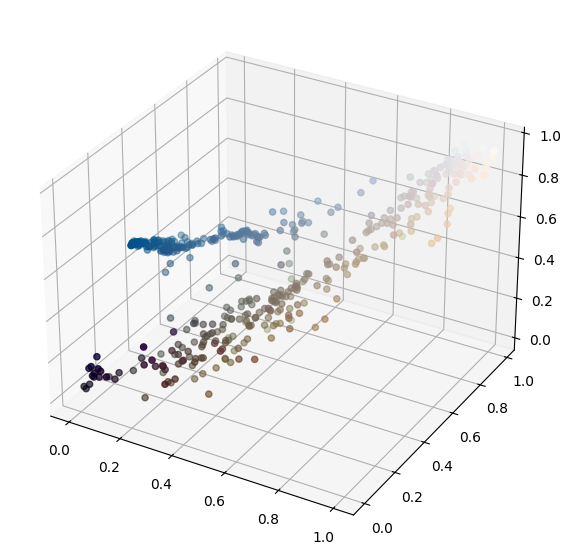

In [63]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

cs = [[x[0], x[1], x[2]]for x in image_subset]
ax.scatter([c[0] for c in image_subset], [c[1] for c in image_subset], [c[2] for c in image_subset], color = cs)

#plt.axis('off')
plt.show()

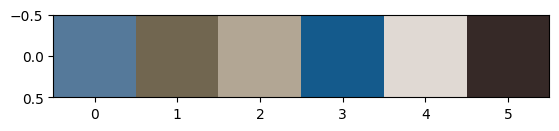

In [64]:
#kmeans = KMeans(n_clusters = 6, n_init="auto").fit(image_array)
centres = kmeans.cluster_centers_
fig = plt.figure()
plt.imshow([centres])
plt.show()

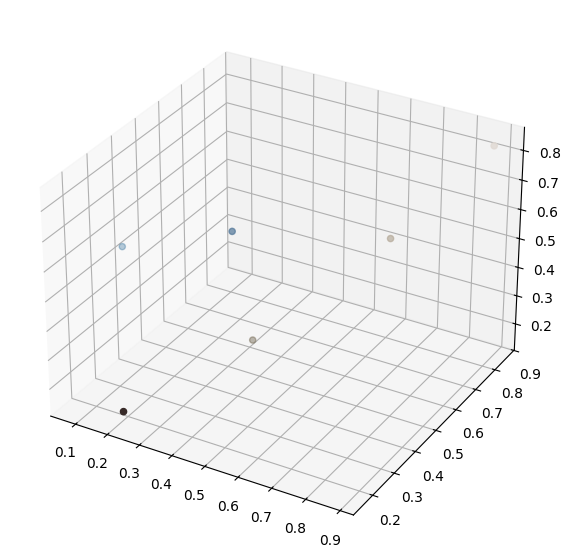

In [65]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
cs = [[x[0], x[1], x[2]]for x in centres]
ax.scatter([c[0] for c in centres], [c[1] for c in centres], [c[2] for c in centres], color = cs)

#plt.axis('off')
plt.show()

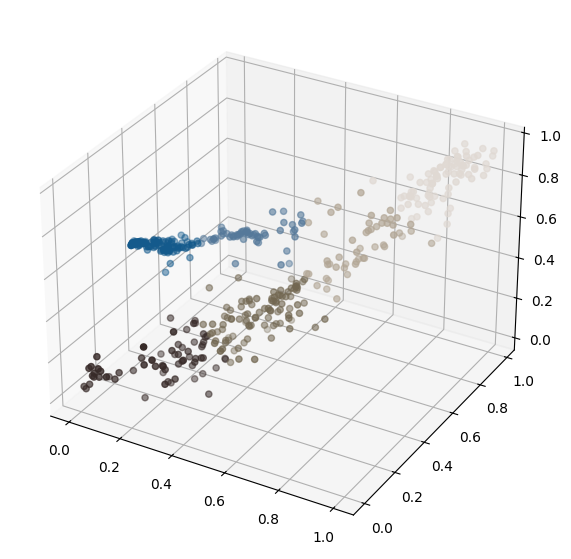

In [66]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

cs = [centres[kmeans.predict([x])] for x in image_subset]
ax.scatter([c[0] for c in image_subset], [c[1] for c in image_subset], [c[2] for c in image_subset], color = cs)

#plt.axis('off')
plt.show()

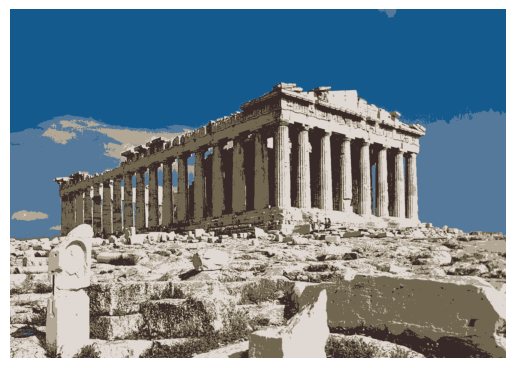

In [67]:
labels = kmeans.predict(image_array)
plt.figure()
plt.axis("off")
plt.imshow(kmeans.cluster_centers_[labels].reshape(w,h,-1))

# PCA
___

In [93]:
#image_array = np.reshape(sample_image, (w*h, d))
pca = PCA(n_components = 2)
colourComponents = pca.fit_transform(image_array)

In [69]:
pca.components_

array([[ 0.72354693,  0.55435206,  0.41130722],
       [-0.58095773,  0.16725412,  0.79656398]])

In [70]:
pca.mean_

array([0.40019626, 0.47289288, 0.51532772])

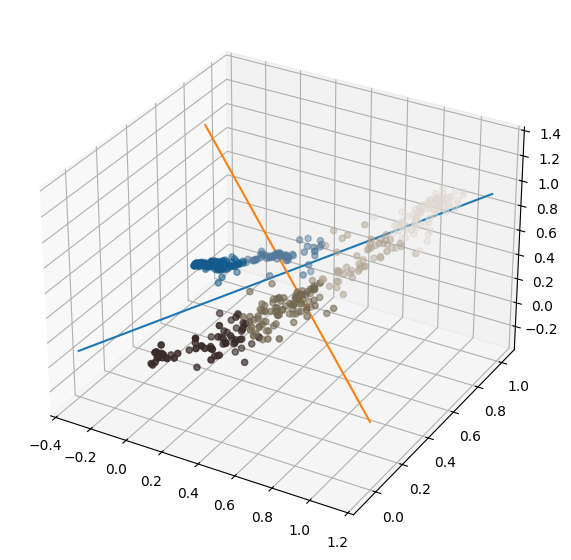

In [71]:
pcaV1s = pca.mean_-pca.components_[0]
pcaV1e = pca.mean_+pca.components_[0]

pcaV2s = pca.mean_-pca.components_[1]
pcaV2e = pca.mean_+pca.components_[1]


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')

cs = [centres[kmeans.predict([x])] for x in image_subset]
ax.scatter([c[0] for c in image_subset], [c[1] for c in image_subset], [c[2] for c in image_subset], color = cs)

ax.plot([pcaV1s[0], pcaV1e[0]], [pcaV1s[1],pcaV1e[1]],zs=[pcaV1s[2],pcaV1e[2]])
ax.plot([pcaV2s[0], pcaV2e[0]], [pcaV2s[1],pcaV2e[1]],zs=[pcaV2s[2],pcaV2e[2]])

#plt.axis('off')
plt.show()

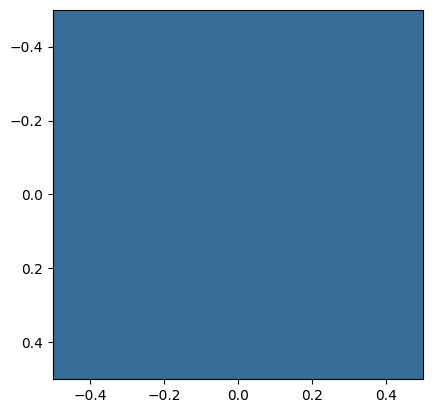

In [72]:
#image_subset = random.sample(list(image_array), 500)
fig = plt.figure()
plt.imshow([[image_subset[0]]])
plt.show()

In [73]:
image_subset[0]

array([0.21960784, 0.42745098, 0.58431373])

In [74]:
pcaTranslated = pca.transform([image_subset[0]])
pcaTranslated

array([[-0.12748056,  0.15226566]])

In [75]:
pcaTranslatedBack = pca.inverse_transform(pcaTranslated)[0]

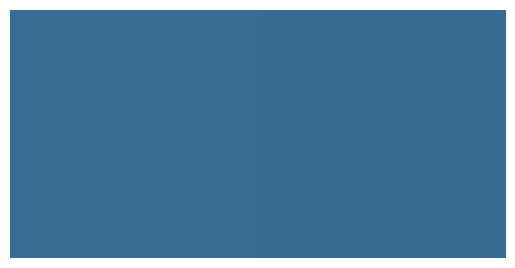

In [76]:
fig = plt.figure()
plt.imshow([[image_subset[0],pcaTranslatedBack]])
plt.axis('off')
plt.show()

In [77]:
image_subset[0], pcaTranslatedBack

(array([0.21960784, 0.42745098, 0.58431373]),
 array([0.21949818, 0.42769083, 0.58418338]))

In [86]:
kmeans2 = KMeans(n_clusters = 6, n_init="auto").fit(colourComponents)

TypeError: Invalid shape (804, 1144, 2) for image data

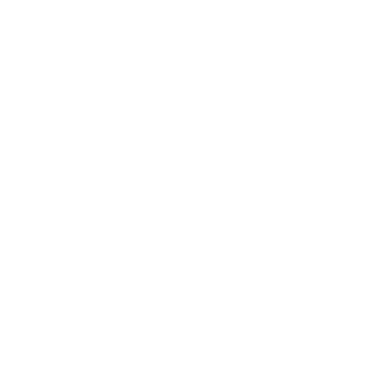

In [95]:
labels2 = kmeans2.predict(colourComponents)
plt.figure()
plt.axis("off")
plt.imshow(kmeans2.cluster_centers_[labels2].reshape(w,h,-1))

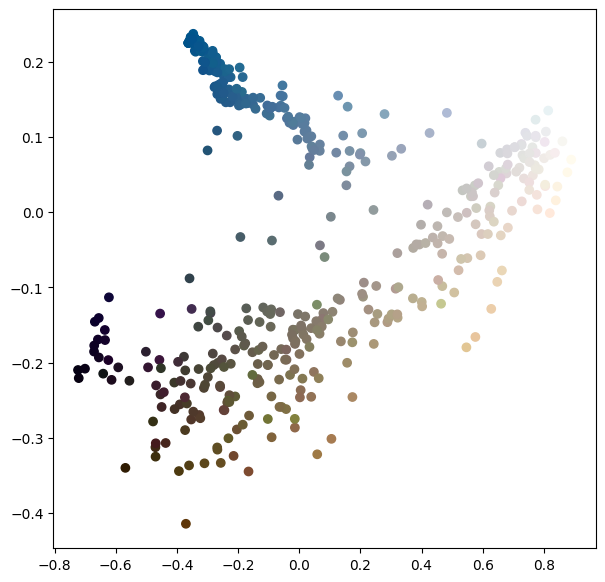

In [96]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot()
cs = [[x[0], x[1], x[2]]for x in image_subset]
ax.scatter([pca.transform([c])[0][0] for c in image_subset], [pca.transform([c])[0][1] for c in image_subset], color = cs)

plt.show()

# SOM
___

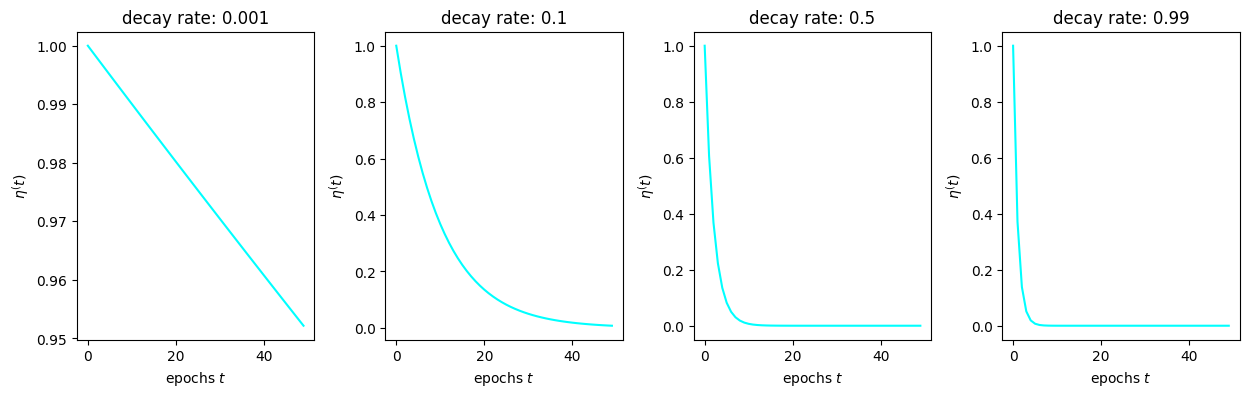

In [97]:
epochs = np.arange(0, 50)
lr_decay = [0.001, 0.1, 0.5, 0.99]
fig,ax = plt.subplots(nrows=1, ncols=4, figsize=(15,4))
plt_ind = np.arange(4) + 141
for decay, ind in zip(lr_decay, plt_ind):
    plt.subplot(ind)
    learn_rate = np.exp(-epochs * decay)
    plt.plot(epochs, learn_rate, c='cyan')
    plt.title('decay rate: ' + str(decay))
    plt.xlabel('epochs $t$')
    plt.ylabel('$\eta^(t)$')
fig.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

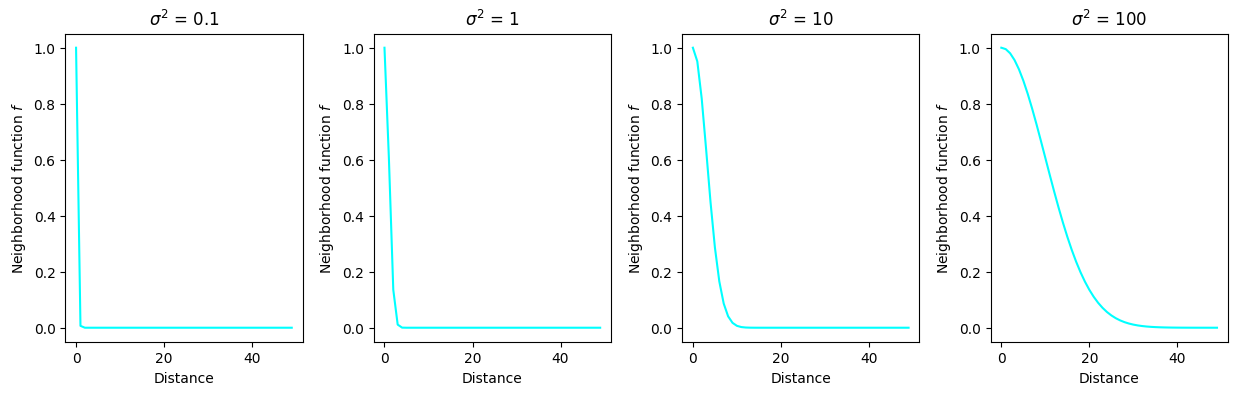

In [98]:
distance = np.arange(0, 50)
sigma_sq = [0.1, 1, 10, 100]
fig,ax = plt.subplots(nrows=1, ncols=4, figsize=(15,4))
plt_ind = np.arange(4) + 141
for s, ind in zip(sigma_sq, plt_ind):
    plt.subplot(ind)
    f = np.exp(-distance ** 2 / 2 / s)
    plt.plot(distance, f, c='cyan')
    plt.title('$\sigma^2$ = ' + str(s))
    plt.xlabel('Distance')
    plt.ylabel('Neighborhood function $f$')
fig.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

### Normalise-Denormalise

In [99]:
def normalise(train, p):
    min_d = np.min(train)
    max_d = np.max(train)
    normalised_p = (p-min_d)/(max_d - min_d)
    return normalised_p

In [100]:
def denormalise(train, p):
    min_d = np.min(train)
    max_d = np.max(train)
    denormalised_p = p * (max_d - min_d) + min_d
    return denormalised_p

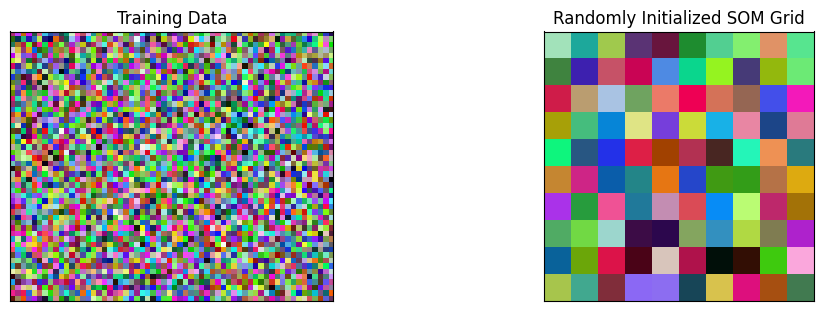

In [102]:
# Dimensions of the SOM grid
m = 10
n = 10
# Number of training examples
n_x = 3000
rand = np.random.RandomState(0)
# Initialize the training data
train_data = rand.randint(0, 255, (n_x, 3))

# Normalised Training Data
n_train_data = normalise(train_data, train_data)

# Initialize the SOM randomly
SOM = rand.uniform(0, 1, (m, n, 3))

# to show the SOM in the original vector space:
oSOM = denormalise(train_data, SOM)

# Display both the training matrix and the SOM grid
fig, ax = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 3.5), 
    subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(train_data.reshape(50, 60, 3))
ax[0].title.set_text('Training Data')
ax[1].imshow(oSOM.astype(int))
ax[1].title.set_text('Randomly Initialized SOM Grid')

In [117]:
# Return the (g,h) index of the BMU in the grid
def find_BMU(SOM,x):
    distSq = (np.square(SOM - x)).sum(axis=2)
    return np.unravel_index(np.argmin(distSq, axis=None), distSq.shape)

# Update the weights of the SOM cells when given a single training example
# and the model parameters along with BMU coordinates as a tuple
def update_weights(SOM, train_ex, learn_rate, radius_sq, 
                   BMU_coord, step=3):
    g, h = BMU_coord
    #if radius is close to zero then only BMU is changed
    if radius_sq < 1e-3:
        SOM[g,h,:] += learn_rate * (train_ex - SOM[g,h,:])
        return SOM
    # Change all cells in a small neighborhood of BMU
    for i in range(max(0, g-step), min(SOM.shape[0], g+step)):
        for j in range(max(0, h-step), min(SOM.shape[1], h+step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / 2 / radius_sq)
            SOM[i,j,:] += learn_rate * dist_func * (train_ex - SOM[i,j,:])   
    return SOM    

# Main routine for training an SOM. It requires an initialized SOM grid
# or a partially trained grid as parameter
def train_SOM(SOM, train_data, learn_rate = .1, radius_sq = 1, 
             lr_decay = .1, radius_decay = .1, epochs = 10):    
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    for epoch in np.arange(0, epochs):
        rand.shuffle(train_data)      
        for train_ex in train_data:
            g, h = find_BMU(SOM, train_ex)
            SOM = update_weights(SOM, train_ex, 
                                 learn_rate, radius_sq, (g,h))
        # Update learning rate and radius
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)            
    return SOM

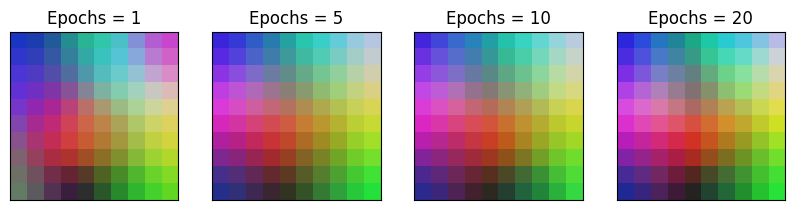

In [103]:
fig, ax = plt.subplots(
    nrows=1, ncols=4, figsize=(10, 3.5), 
    subplot_kw=dict(xticks=[], yticks=[]))
total_epochs = 0
for epochs, i in zip([1, 4, 5, 10], range(0,4)):
    total_epochs += epochs
    SOM = train_SOM(SOM, n_train_data, epochs=epochs)
    
    oSOM = denormalise(train_data, SOM)    
    ax[i].imshow(oSOM.astype(int))
    ax[i].title.set_text('Epochs = ' + str(total_epochs))

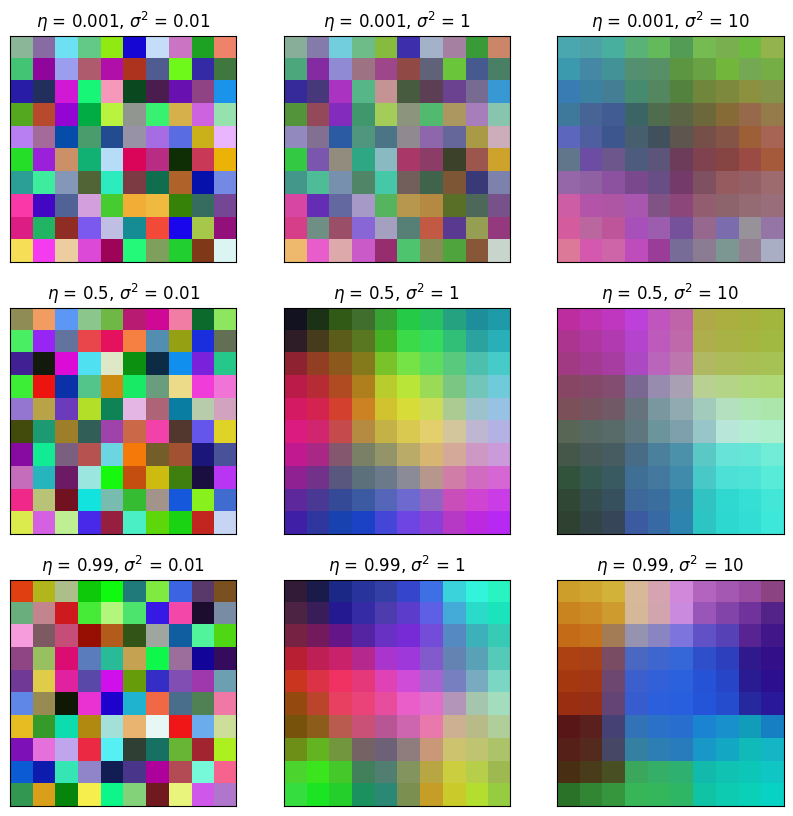

In [104]:
fig, ax = plt.subplots(
    nrows=3, ncols=3, figsize=(10, 10), 
    subplot_kw=dict(xticks=[], yticks=[]))

# Initialize the SOM randomly to the same state

for learn_rate, i in zip([0.001, 0.5, 0.99], [0, 1, 2]):
    for radius_sq, j in zip([0.01, 1, 10], [0, 1, 2]):
        rand = np.random.RandomState(0)
        SOM = rand.uniform(0, 1, (m, n, 3))        
        SOM = train_SOM(SOM, n_train_data, epochs = 5,
                        learn_rate = learn_rate, 
                        radius_sq = radius_sq)
        oSOM = denormalise(train_data, SOM)
        ax[i][j].imshow(oSOM.astype(int))
        ax[i][j].title.set_text('$\eta$ = ' + str(learn_rate) + 
                                ', $\sigma^2$ = ' + str(radius_sq))

In [105]:
#Quantization Error
import scipy
def calculateQE(SOM,data):
    sumSqDist = 0
    for d in data:
        g,h = find_BMU(SOM, d)
        v1 = SOM[g,h]
        v2 = d
        sumSqDist += scipy.spatial.distance.cdist([v1],[v2],'sqeuclidean')[0][0]
    QE = sumSqDist/len(data)
    return QE

In [106]:
#Topological Error
def calculateTE(SOM,data):
    failed = 0
    for d in data:
        g1,h1 = find_BMU(SOM,d)
        g2,h2 = find_BMU_2(SOM,d)
        dist = scipy.spatial.distance.cityblock([g1,h1], [g2,h2])
        if dist>1:
            failed+=1
    return failed/len(data)

In [108]:
# Return the (g,h) index of the BMU in the grid
def find_BMU_2(SOM,x):
    distSq = (np.square(SOM - x)).sum(axis=2)
    return np.unravel_index(np.argpartition(distSq, 2, axis=None)[2], distSq.shape)

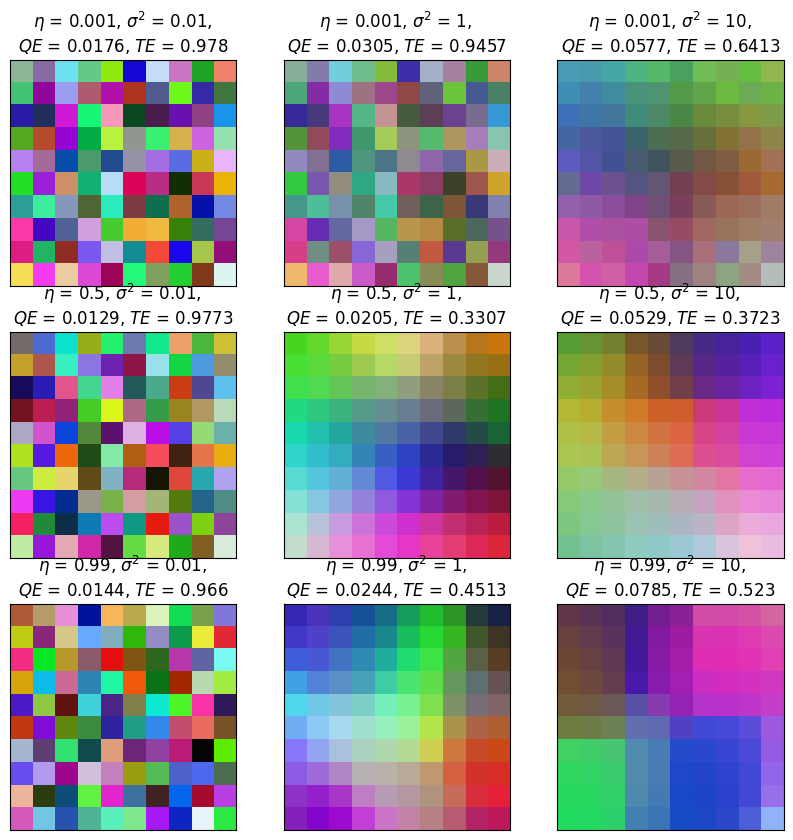

In [109]:
fig, ax = plt.subplots(
    nrows=3, ncols=3, figsize=(10, 10), 
    subplot_kw=dict(xticks=[], yticks=[]))

# Initialize the SOM randomly to the same state

SOMS = []

for learn_rate, i in zip([0.001, 0.5, 0.99], [0, 1, 2]):
    for radius_sq, j in zip([0.01, 1, 10], [0, 1, 2]):
        rand = np.random.RandomState(0)
        SOM = rand.uniform(0, 1, (m, n, 3))        
        SOM = train_SOM(SOM, n_train_data, epochs = 5,
                        learn_rate = learn_rate, 
                        radius_sq = radius_sq)
        QE = round(calculateQE(SOM, n_train_data), 4)
        TE = round(calculateTE(SOM, n_train_data), 4)
        SOMS.append(SOM)
        oSOM = denormalise(train_data, SOM)
        ax[i][j].imshow(oSOM.astype(int))
        ax[i][j].title.set_text('$\eta$ = ' + str(learn_rate) + 
                                ', $\sigma^2$ = ' + str(radius_sq) + 
                               ', \n$QE$ = ' + str(QE) + 
                               ', $TE$ = ' + str(TE))

In [110]:
find_BMU_2(SOM, n_train_data[0])

(0, 6)

In [111]:
calculateQE(SOM, n_train_data)

0.07848099546203255

In [113]:
calculateTE(SOM, train_data)

0.841

In [114]:
import sklearn

def euclidean(a, b):
    return np.linalg.norm(a-b)

def u_matrix(lattice):
    """Builds a U-matrix on top of the trained lattice.

        Parameters
        ---
        lattice : list

            The SOM generated lattice

        Returns
        ---
        The lattice of the shape (R,C):

        R - number of rows; C - number of columns;
        """
    X, Y, Z = lattice.shape
    u_values = np.empty((X,Y), dtype=np.float64)

    for y in range(Y):
        for x in range(X):
            current = lattice[x,y]
            dist = 0
            num_neigh = 0
            # left
            if x-1 >= 0:
                #middle
                vec = lattice[x-1,y]
                dist += euclidean(current, vec)
                num_neigh += 1
                if y - 1 >= 0:
                    #sup
                    vec = lattice[x-1, y-1]
                    dist += euclidean(current, vec)
                    num_neigh += 1
                if y + 1 < Y:
                    # down
                    vec = lattice[x-1,y+1]
                    dist += euclidean(current, vec)
                    num_neigh += 1
            # middle
            if y - 1 >= 0:
                # up
                vec = lattice[x,y-1]
                dist += euclidean(current, vec)
                num_neigh += 1
            # down
            if y + 1 < Y:
                vec = lattice[x,y+1]
                dist += euclidean(current, vec)
                num_neigh += 1
            # right
            if x + 1 < X:
                # middle
                vec = lattice[x+1,y]
                dist += euclidean(current, vec)
                num_neigh += 1
                if y - 1 >= 0:
                    #up
                    vec = lattice[x+1,y-1]
                    dist += euclidean(current, vec)
                    num_neigh += 1
                if y + 1 < lattice.shape[1]:
                    # down
                    vec = lattice[x+1,y+1]
                    dist += euclidean(current, vec)
                    num_neigh += 1
            u_values[x,y] = dist / num_neigh
    u_values = (u_values - 1) * -1
    return u_values

In [115]:
u_matrix(SOM)

array([[0.94855006, 0.93437977, 0.87639805, 0.81041183, 0.84757102,
        0.82056651, 0.83214403, 0.93227288, 0.91394844, 0.8701731 ],
       [0.94086446, 0.93257347, 0.86513726, 0.79746776, 0.84933019,
        0.83760662, 0.85873403, 0.93792065, 0.92512731, 0.9222139 ],
       [0.94503235, 0.9338566 , 0.83576136, 0.77039289, 0.84966775,
        0.85920668, 0.87950409, 0.94616723, 0.93940346, 0.93944064],
       [0.9340114 , 0.92430041, 0.81049069, 0.72287712, 0.84161515,
        0.86749871, 0.87769867, 0.92633412, 0.92783274, 0.92970031],
       [0.90741078, 0.89312977, 0.78323267, 0.74959283, 0.8015496 ,
        0.79134747, 0.76756166, 0.79069762, 0.82203041, 0.83599332],
       [0.77805454, 0.79021989, 0.72755646, 0.77660782, 0.81943703,
        0.77687678, 0.78501692, 0.78608488, 0.74925686, 0.79480586],
       [0.80959246, 0.82445402, 0.7515849 , 0.8139287 , 0.85574753,
        0.85209821, 0.9257542 , 0.92705795, 0.84177232, 0.80878773],
       [0.9489668 , 0.94524816, 0.8260658

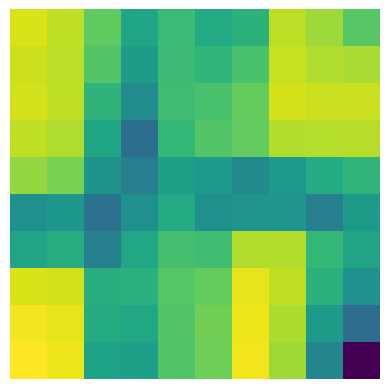

In [116]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.imshow(u_matrix(SOM))
plt.axis('off')
plt.show()

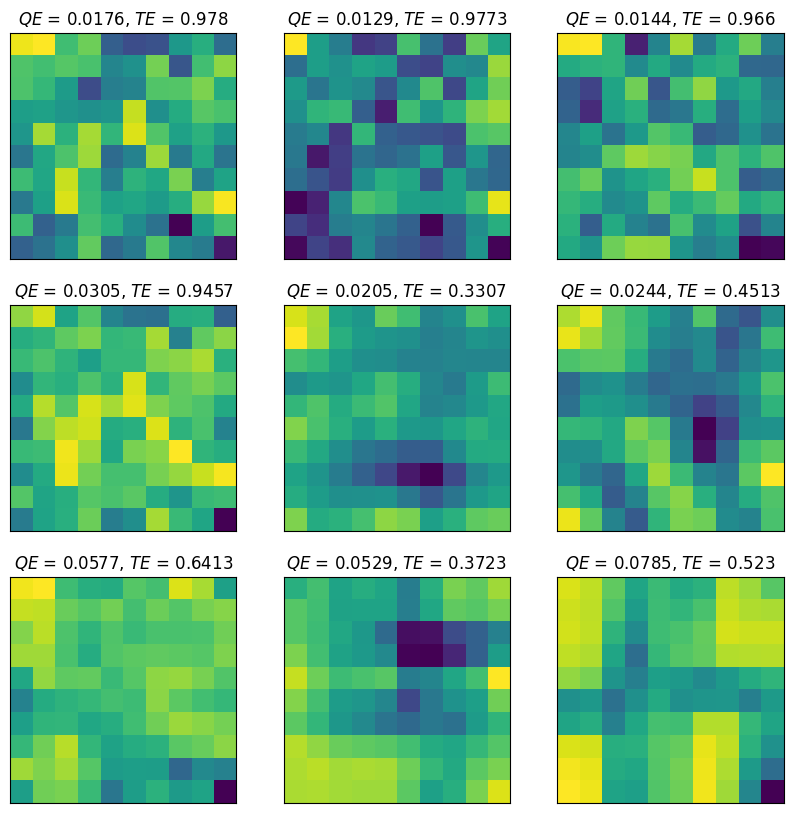

In [118]:
fig, ax = plt.subplots(
    nrows=3, ncols=3, figsize=(10, 10), 
    subplot_kw=dict(xticks=[], yticks=[]))

# Initialize the SOM randomly to the same state

for s, n in zip(SOMS, range(len(SOMS))):
        QE = round(calculateQE(s, n_train_data), 4)
        TE = round(calculateTE(s, n_train_data), 4)
        
        i = n%3
        j = n//3
        
        ax[i][j].imshow(u_matrix(s))
        ax[i][j].title.set_text('$QE$ = ' + str(QE) + 
                               ', $TE$ = ' + str(TE))

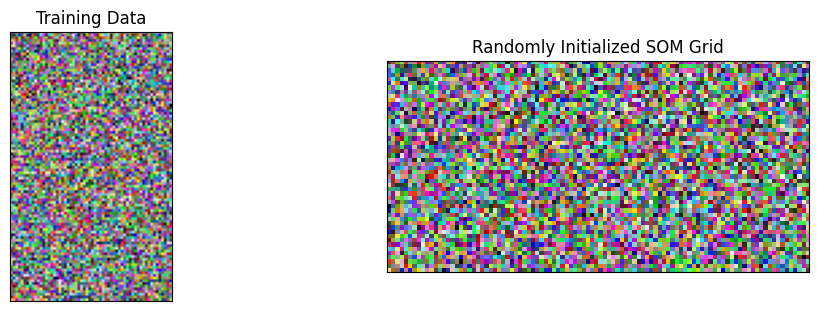

In [137]:
# Dimensions of the SOM grid
m = 50
n = 100
# Number of training examples
n_x = 6000
rand = np.random.RandomState(0)
# Initialize the training data
train_data = rand.randint(0, 255, (n_x, 3))

# Normalised Training Data
n_train_data = normalise(train_data, train_data)

# Initialize the SOM randomly
SOM = rand.uniform(0, 1, (m, n, 3))

# to show the SOM in the original vector space:
oSOM = denormalise(train_data, SOM)

# Display both the training matrix and the SOM grid
fig, ax = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 3.5), 
    subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(train_data.reshape(100, 60, 3))
ax[0].title.set_text('Training Data')
ax[1].imshow(oSOM.astype(int))
ax[1].title.set_text('Randomly Initialized SOM Grid')

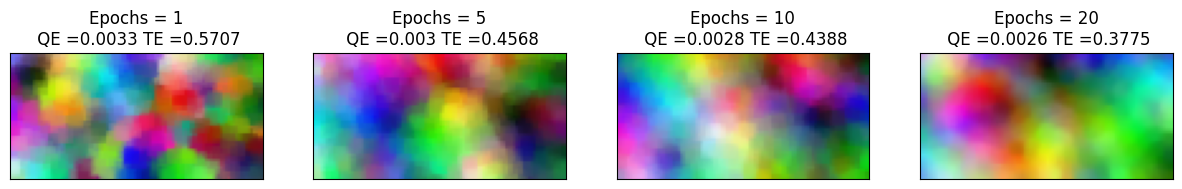

In [138]:
fig, ax = plt.subplots(
    nrows=1, ncols=4, figsize=(15, 5), 
    subplot_kw=dict(xticks=[], yticks=[]))
total_epochs = 0
for epochs, i in zip([1, 4, 5, 10], range(0,4)):
    total_epochs += epochs
    SOM = train_SOM(SOM, n_train_data, learn_rate=0.5, radius_sq=10, epochs=epochs)
    
    QE = round(calculateQE(SOM, n_train_data), 4)
    TE = round(calculateTE(SOM, n_train_data), 4)
    
    oSOM = denormalise(train_data, SOM)    
    ax[i].imshow(oSOM.astype(int))
    ax[i].title.set_text('Epochs = ' + str(total_epochs) + '\n QE =' + str(QE) + ' TE =' + str(TE))

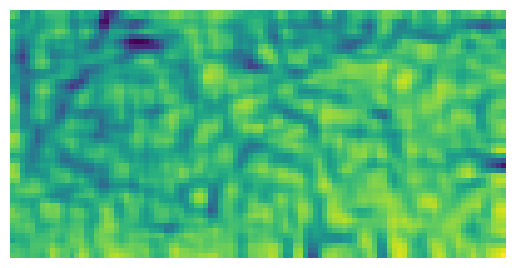

In [139]:
fig = plt.figure()
plt.imshow(u_matrix(SOM))
plt.axis('off')
plt.show()

In [140]:
def activate(train_data, SOM, p):
    normalP = normalise(train_data, p)
    activatedSOM = [[euclidean(normalP, c) for c in r] for r in SOM]
    actviatedSOM = (np.array(activatedSOM) - 1)*-1
    return actviatedSOM

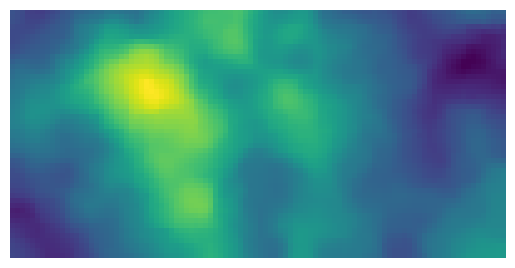

In [141]:
activate(train_data, SOM, [200,0,0])
fig = plt.figure()
plt.imshow(activate(train_data, SOM, [200,0,0]))
plt.axis('off')
plt.show()

In [142]:
#!pip install numbasom

In [143]:
import numbasom
from numbasom import SOM

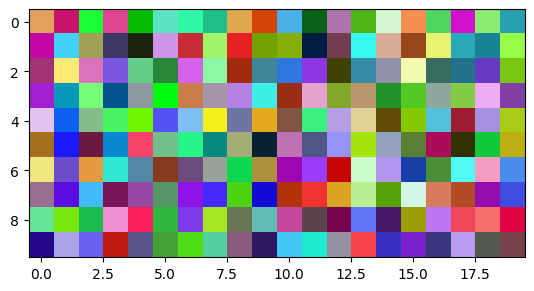

In [144]:
data = np.random.random([200,3])
dataViz = data.reshape([10,20,3])
plt.imshow(dataViz)

In [145]:
som = SOM(som_size=(50,100), is_torus=False)
lattice = som.train(data, num_iterations=1)

SOM training took: 1.471943 seconds.


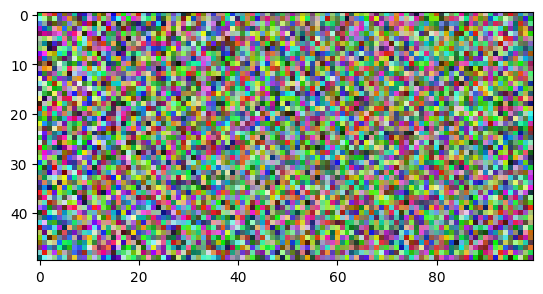

In [146]:
plt.imshow(lattice)
plt.show()

SOM training took: 0.001709 seconds.


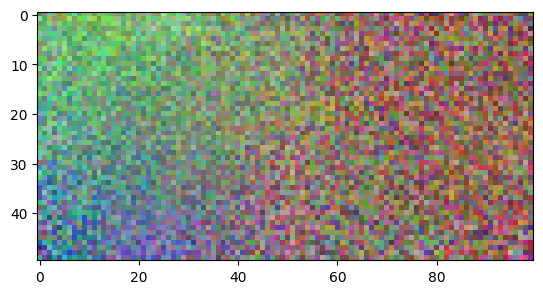

In [150]:
lattice = som.train(data, num_iterations=100)
plt.imshow(lattice)
plt.show()

SOM training took: 0.016802 seconds.


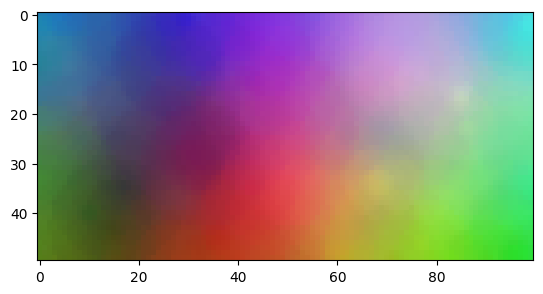

In [151]:
lattice = som.train(data, num_iterations=1000)
plt.imshow(lattice)
plt.show()

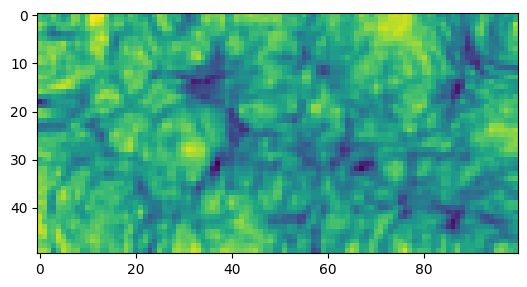

In [152]:
um = numbasom.u_matrix(lattice)
numbasom.plot_u_matrix(um, fig_size=(6.2,6.2))

SOM training took: 0.300580 seconds.


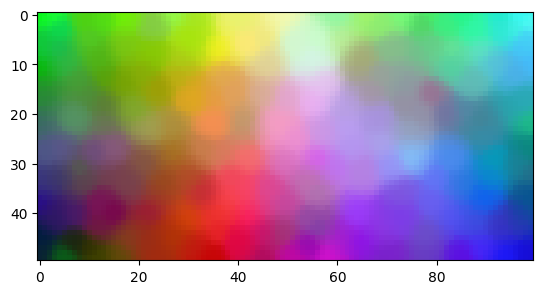

In [153]:
lattice = som.train(data, num_iterations=15000)
plt.imshow(lattice)
plt.show()

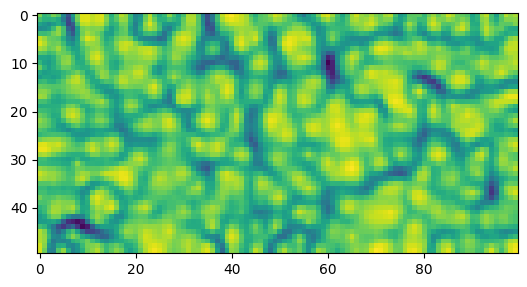

In [154]:
um = numbasom.u_matrix(lattice)
numbasom.plot_u_matrix(um, fig_size=(6.2,6.2))